Install mindat

In [ ]:
%pip install openmindat networkx pyvis

Setup the API key for Mindat API

In [ ]:
import os
import yaml
import gdown

file_id = '1U_S026tWPDz13bwdrv1l7cNUCnDfXHBa'
gdown.download(id=file_id, quiet=True)

os.environ['MINDAT_API_KEY'] = yaml.safe_load(open('.mindat_key.yaml'))['MINDAT_KEY']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Query Localities in China with Gold.
I then save the data to a JSON file using the JSON library.

In [ ]:
from openmindat import LocalitiesRetriever
import json

# Initialize LocalitiesRetriever
lr = LocalitiesRetriever()

# Filter by country 'China' and expand 'geomaterials'
lr.country('China').elements_inc("Au").expand("geomaterials")

# Fetch the data from Mindat API
localities = lr.get_dict()

with open("output.json", "w") as f:
    json.dump(localities, f)

Fetching data: 0it [00:00, ?it/s]

Preform analysis

In [ ]:
import json

# Load the data from output.json
with open("output.json", "r") as f:
    data = json.load(f)

# Filter out localities where longitude or latitude is 0 or None
cleaned_results = [
    locality for locality in data['results']
    if 'longitude' in locality and locality['longitude'] is not None and locality['longitude'] != 0
    and 'latitude' in locality and locality['latitude'] is not None and locality['latitude'] != 0
]

# Update the 'results' in the data dictionary
data['results'] = cleaned_results

# Overwrite output.json with the cleaned data
with open("output.json", "w") as f:
    json.dump(data, f, indent=4)

# Add Elevation Data

In [ ]:
import requests
import json
import time

# Load the data from output.json
with open("output.json", "r") as f:
    data = json.load(f)

# Requests were timing out so retry them if necessary
# One large request was also timing out so divide them into smaller chumks
def fetch_elevations_with_retry(data, batch_size=50, max_retries=3):
    url = "https://api.open-elevation.com/api/v1/lookup"
    results_list = data.get('results', [])
    total = len(results_list)

    print(f"Processing {total} locations in batches of {batch_size}...")

    for i in range(0, total, batch_size):
        batch = results_list[i:i + batch_size]
        # Skip if already has elevation from a previous partial run
        if all('elevation' in loc and loc['elevation'] is not None for loc in batch):
            continue

        locations = [{'latitude': loc.get('latitude'), 'longitude': loc.get('longitude')} for loc in batch]

        success = False
        for attempt in range(max_retries):
            try:
                response = requests.post(url, json={'locations': locations}, timeout=30)
                response.raise_for_status()
                elevations = response.json().get('results', [])

                for j, elevation_data in enumerate(elevations):
                    batch[j]['elevation'] = elevation_data.get('elevation')

                print(f"Progress: {min(i + batch_size, total)}/{total}")
                success = True
                break
            except Exception as e:
                wait_time = (attempt + 1) * 5
                print(f"Error at index {i} (attempt {attempt+1}/{max_retries}): {e}. Retrying in {wait_time}s...")
                time.sleep(wait_time)

        if not success:
            print(f"Failed to fetch batch starting at index {i} after {max_retries} attempts.")

        time.sleep(1) # Base politeness delay

# Execute robust update
fetch_elevations_with_retry(data, batch_size=50)

# Save the updated data
with open("output.json", "w") as f:
    json.dump(data, f, indent=4)

print("Finished updating output.json with elevation data.")

Processing 1694 locations in batches of 50...
Progress: 50/1694
Progress: 100/1694
Progress: 150/1694
Progress: 200/1694
Progress: 250/1694
Progress: 300/1694
Progress: 350/1694
Progress: 400/1694
Progress: 450/1694
Progress: 500/1694
Progress: 550/1694
Progress: 600/1694
Progress: 650/1694
Progress: 700/1694
Progress: 750/1694
Progress: 800/1694
Progress: 850/1694
Progress: 900/1694
Progress: 950/1694
Progress: 1000/1694
Progress: 1050/1694
Progress: 1100/1694
Progress: 1150/1694
Progress: 1200/1694
Progress: 1250/1694
Progress: 1300/1694
Progress: 1350/1694
Progress: 1400/1694
Progress: 1450/1694
Progress: 1500/1694
Progress: 1550/1694
Progress: 1600/1694
Progress: 1650/1694
Progress: 1694/1694
Finished updating output.json with elevation data.


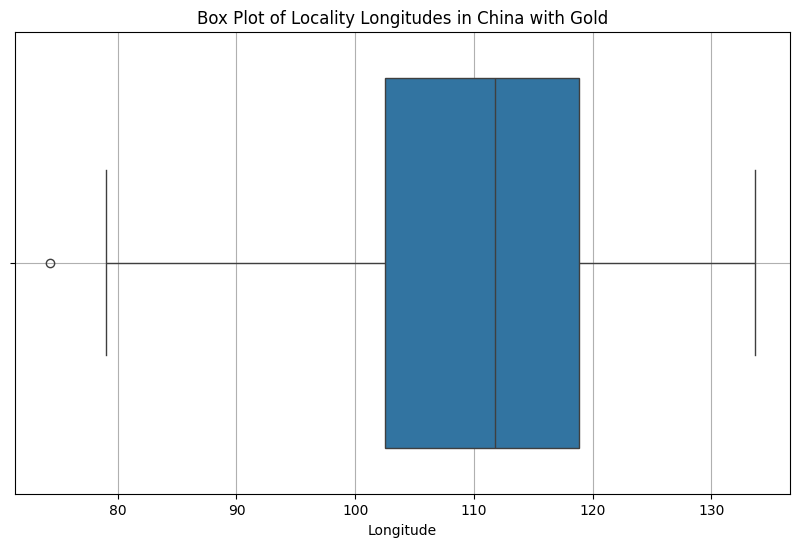

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data from output.json
with open("output.json", "r") as f:
    data = json.load(f)

longitudes = [locality['longitude'] for locality in data['results']]

# Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=longitudes)
plt.title('Box Plot of Locality Longitudes in China with Gold')
plt.xlabel('Longitude')
plt.grid(True)
plt.show()

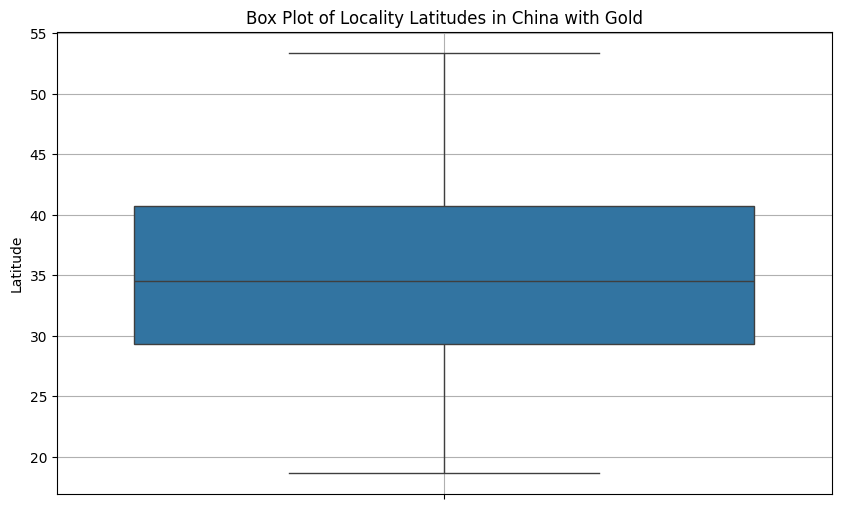

In [ ]:
# Load the data from output.json
with open("output.json", "r") as f:
    data = json.load(f)

latitudes = [locality['latitude'] for locality in data['results']]

# Create a vertical box plot
plt.figure(figsize=(10, 6))
sns.boxplot(y=latitudes)
plt.title('Box Plot of Locality Latitudes in China with Gold')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

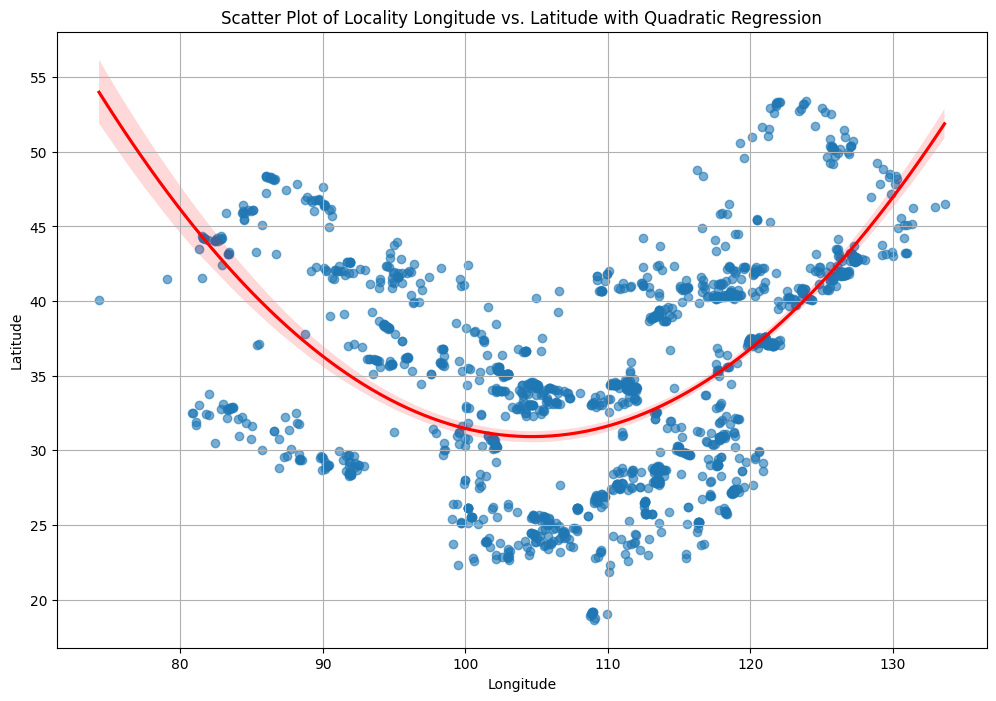

In [ ]:
# Load the data from output.json
with open("output.json", "r") as f:
    data = json.load(f)

longitudes = [loc['longitude'] for loc in data['results']]
latitudes = [loc['latitude'] for loc in data['results']]

# Create a DataFrame for seaborn
df_plot = pd.DataFrame({'longitude': longitudes, 'latitude': latitudes})

# Create a scatter plot with a polynomial regression line (order=2 for quadratic)
plt.figure(figsize=(12, 8))
sns.regplot(x='longitude', y='latitude', data=df_plot, order=2, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Scatter Plot of Locality Longitude vs. Latitude with Quadratic Regression')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

Loaded 1694 gold localities across China.
Lat range:  18.66 – 53.37
Lon range:  74.30 – 133.64
Avg co-occurring elements: 11.1
Section 1 complete — interactive map saved to 'section1_gold_map.html'
Section 2 complete — density heatmap saved to 'section2_gold_heatmap.html'


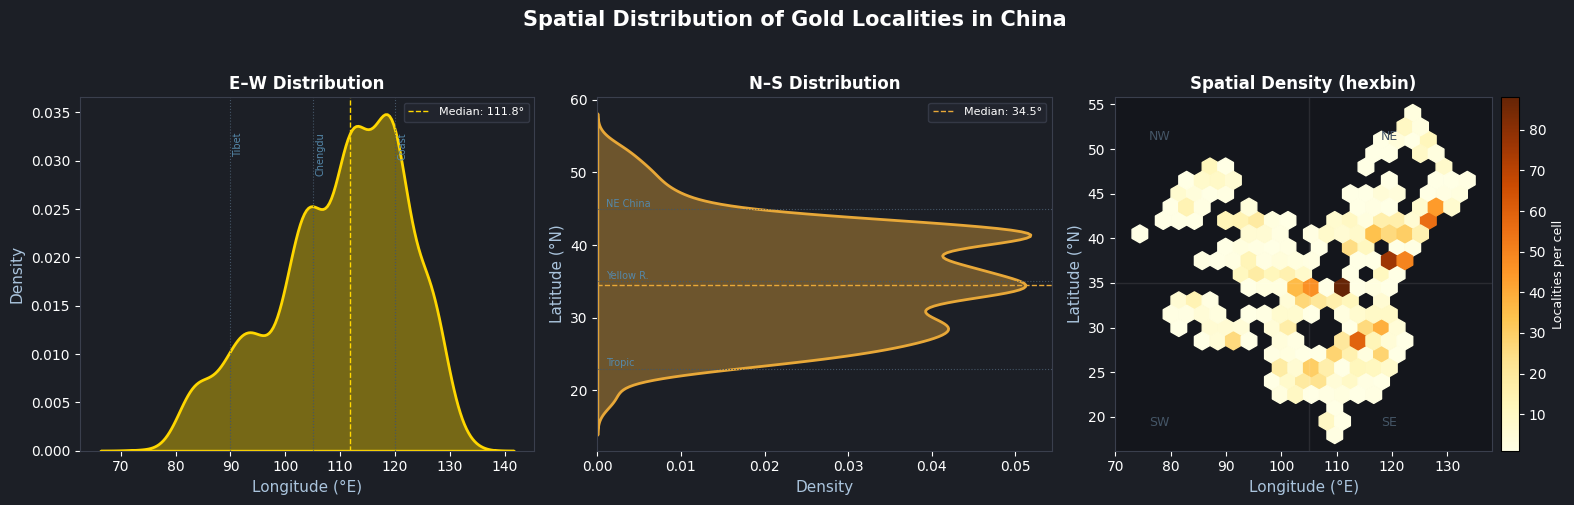

Section 3 complete — spatial distribution figure saved.


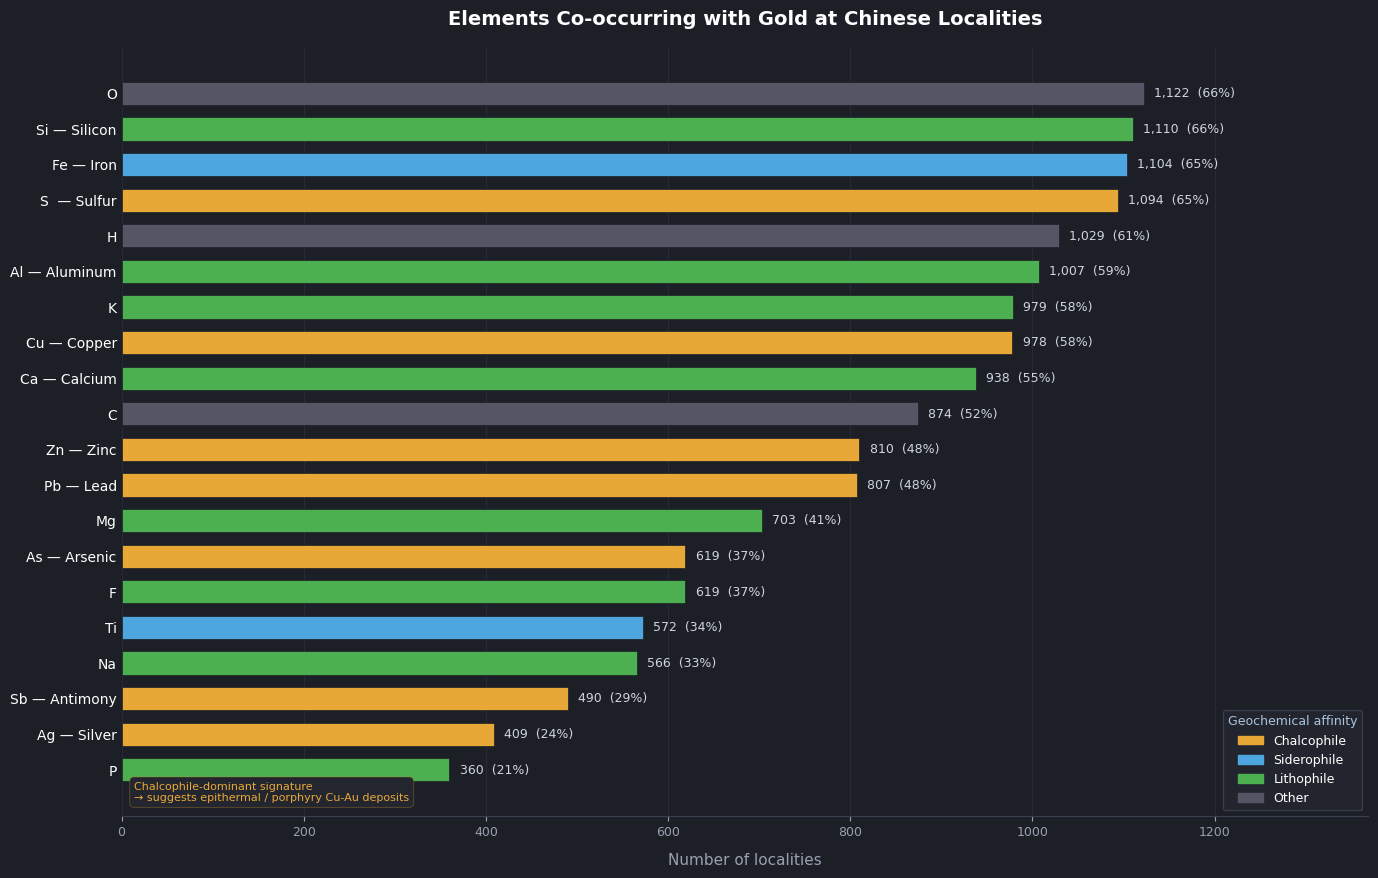

Section 4 complete — co-occurring elements chart saved.

── Outputs ──────────────────────────────────────────────────
  section1_gold_map.html              — interactive dot map
  section2_gold_heatmap.html          — deposit density heatmap
  section3_spatial_distribution.png   — KDE + hexbin spatial analysis
  section4_cooccurring_minerals.png   — co-occurring mineral bar chart


In [ ]:
# -*- coding: utf-8 -*-
"""
China Gold Localities — Visualization Notebook
Dataset: Mindat localities in China containing gold (Au), with lat/lon coordinates
"""

# ============================================================
# SHARED SETUP — Run this after your existing data retrieval cells
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

filepath = '/content/output.json'
with open(filepath, 'r') as f:
    data = json.load(f)

results = data['results']

# Build master DataFrame — one row per locality
# 'elements' is a dash-delimited string e.g. '-Au-Ag-Cu-Fe-'
# Split on '-' and filter empty strings to get a clean list
def parse_elements(raw):
    if not raw:
        return []
    return [e for e in str(raw).split('-') if e.strip()]

rows = []
for loc in results:
    raw = loc.get('elements', '') or ''
    all_elems = parse_elements(raw)
    # Filter out Au itself so co-occurrence analysis is meaningful
    other_elements = [e for e in all_elems if e != 'Au']
    element_count = len(other_elements)

    rows.append({
        'name':          loc.get('txt') or loc.get('name', 'Unknown'),
        'lat':           loc.get('latitude'),
        'lon':           loc.get('longitude'),
        'description':   loc.get('description_short', ''),
        'element_count': element_count,
        'elements':      other_elements,
        'all_elements':  all_elems,
        'discovery_year': pd.to_numeric(loc.get('discovery_year'), errors='coerce'),
        'loc_type':      loc.get('locality_type', ''),
        'age':           loc.get('age', ''),
        'has_silver':    'Ag' in all_elems,
        'has_copper':    'Cu' in all_elems,
        'has_lead':      'Pb' in all_elems,
        'has_zinc':      'Zn' in all_elems,
        'has_iron':      'Fe' in all_elems,
        'has_arsenic':   'As' in all_elems,
    })

df = pd.DataFrame(rows).dropna(subset=['lat', 'lon'])
df = df[(df['lon'] != 0) & (df['lat'] != 0)]  # already cleaned but double-check

print(f"Loaded {len(df)} gold localities across China.")
print(f"Lat range:  {df['lat'].min():.2f} – {df['lat'].max():.2f}")
print(f"Lon range:  {df['lon'].min():.2f} – {df['lon'].max():.2f}")
print(f"Avg co-occurring elements: {df['element_count'].mean():.1f}")


# ============================================================
# SECTION 1 — Dot Map of Gold Localities
# ============================================================
"""
Every locality plotted on a China basemap.
Color = number of associated minerals (richer deposits show brighter).
Size = also scales with mineral count.
Reveals the spatial clustering of gold deposits — NE vs SW vs coastal.
"""

import folium
from folium.plugins import MarkerCluster, HeatMap

# Color by mineral richness
def richness_color(n):
    if n >= 10: return '#ffd700'   # gold  — very rich
    elif n >= 5: return '#f4a460'  # tan   — moderate
    elif n >= 2: return '#cd853f'  # brown — sparse
    else:        return '#8b6914'  # dark  — single mineral

m = folium.Map(
    location=[35.5, 103.5],
    zoom_start=4,
    tiles='CartoDB dark_matter'
)

cluster = MarkerCluster(
    options={'maxClusterRadius': 40, 'spiderfyOnMaxZoom': True}
).add_to(m)

for _, row in df.iterrows():
    color = richness_color(row['element_count'])
    assoc = ', '.join(row['elements'][:5]) if row['elements'] else 'Gold only'
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(4, min(12, 3 + row['element_count'] * 0.8)),
        color='#333',
        weight=0.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"Minerals ({row['element_count']}): {assoc}",
            max_width=240
        ),
        tooltip=f"{row['name']} ({row['element_count']} minerals)"
    ).add_to(cluster)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:#23262f;border:1px solid #334;border-radius:8px;
     padding:12px 16px;font-family:monospace;color:white;font-size:12px;">
  <b>Associated minerals</b><br>
  <span style="color:#ffd700">●</span> 10+&nbsp;&nbsp;
  <span style="color:#f4a460">●</span> 5–9&nbsp;&nbsp;
  <span style="color:#cd853f">●</span> 2–4&nbsp;&nbsp;
  <span style="color:#8b6914">●</span> 1
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('section1_gold_map.html')
print("Section 1 complete — interactive map saved to 'section1_gold_map.html'")


# ============================================================
# SECTION 2 — Heatmap of Deposit Density
# ============================================================
"""
A continuous density heatmap over China showing WHERE gold deposits
concentrate geographically. Overlaid on the same folium map as the dots.
Reveals belts and clusters invisible from the dot map alone.
"""

m2 = folium.Map(
    location=[35.5, 103.5],
    zoom_start=4,
    tiles='CartoDB positron'
)

# Weight heatmap by mineral count (richer deposits pull harder)
heat_data = [
    [row['lat'], row['lon'], max(1, row['element_count'])]
    for _, row in df.iterrows()
]

HeatMap(
    heat_data,
    radius=25,
    blur=18,
    max_zoom=8,
    gradient={0.2: '#1a1a6e', 0.4: '#2b5ea7', 0.6: '#d4a017', 0.8: '#f5c518', 1.0: '#ffd700'}
).add_to(m2)

m2.save('section2_gold_heatmap.html')
print("Section 2 complete — density heatmap saved to 'section2_gold_heatmap.html'")


# ============================================================
# SECTION 3 — Longitude & Latitude Distribution + Spatial Quadrant
# ============================================================
"""
Three-panel figure:
  Left:   KDE of longitudes — shows E-W spread, peaks at major belts
  Center: KDE of latitudes — shows N-S spread
  Right:  2D hexbin of (lon, lat) — a spatial density map in matplotlib
          color = count of localities per hex cell

Replaces the existing box plots with something analytically richer.
"""

fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('#1c1f26')

# China bounding box roughly
LON_MIN, LON_MAX = 73, 135
LAT_MIN, LAT_MAX = 18, 54

df_clip = df[(df['lon'].between(LON_MIN, LON_MAX)) &
             (df['lat'].between(LAT_MIN, LAT_MAX))]

# ── Panel 1: Longitude KDE
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_facecolor('#1c1f26')
sns.kdeplot(data=df_clip, x='lon', fill=True, color='#ffd700',
            alpha=0.4, linewidth=2, ax=ax1)
ax1.axvline(df_clip['lon'].median(), color='#ffd700', linestyle='--',
            linewidth=1, label=f"Median: {df_clip['lon'].median():.1f}°")
ax1.set_xlabel('Longitude (°E)', color='#aac4dd', fontsize=11)
ax1.set_ylabel('Density', color='#aac4dd', fontsize=11)
ax1.set_title('E–W Distribution', color='white', fontsize=12, fontweight='bold')
ax1.tick_params(colors='white')
ax1.spines[['top','right','left','bottom']].set_color('#3a3f4d')
ax1.legend(fontsize=8, facecolor='#23262f', labelcolor='white',
           edgecolor='#3a3f4d')

# Major longitude references
for lon, label in [(90,'Tibet'), (105,'Chengdu'), (120,'Coast')]:
    ax1.axvline(lon, color='#445566', linewidth=0.8, linestyle=':')
    ax1.text(lon + 0.5, ax1.get_ylim()[1] * 0.9, label,
             color='#5588aa', fontsize=7, rotation=90, va='top')

# ── Panel 2: Latitude KDE
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_facecolor('#1c1f26')
sns.kdeplot(data=df_clip, y='lat', fill=True, color='#e8a838',
            alpha=0.4, linewidth=2, ax=ax2)
ax2.axhline(df_clip['lat'].median(), color='#e8a838', linestyle='--',
            linewidth=1, label=f"Median: {df_clip['lat'].median():.1f}°")
ax2.set_ylabel('Latitude (°N)', color='#aac4dd', fontsize=11)
ax2.set_xlabel('Density', color='#aac4dd', fontsize=11)
ax2.set_title('N–S Distribution', color='white', fontsize=12, fontweight='bold')
ax2.tick_params(colors='white')
ax2.spines[['top','right','left','bottom']].set_color('#3a3f4d')
ax2.legend(fontsize=8, facecolor='#23262f', labelcolor='white',
           edgecolor='#3a3f4d')

for lat, label in [(23,'Tropic'), (35,'Yellow R.'), (45,'NE China')]:
    ax2.axhline(lat, color='#445566', linewidth=0.8, linestyle=':')
    ax2.text(ax2.get_xlim()[1] * 0.02, lat + 0.3, label,
             color='#5588aa', fontsize=7)

# ── Panel 3: 2D Hexbin density
ax3 = fig.add_subplot(1, 3, 3)
ax3.set_facecolor('#14161c')
hb = ax3.hexbin(
    df_clip['lon'], df_clip['lat'],
    gridsize=22,
    cmap='YlOrBr',
    mincnt=1,
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
)
cb = fig.colorbar(hb, ax=ax3, pad=0.02)
cb.set_label('Localities per cell', color='white', fontsize=9)
cb.ax.tick_params(colors='white')
ax3.set_xlabel('Longitude (°E)', color='#aac4dd', fontsize=11)
ax3.set_ylabel('Latitude (°N)', color='#aac4dd', fontsize=11)
ax3.set_title('Spatial Density (hexbin)', color='white',
              fontsize=12, fontweight='bold')
ax3.tick_params(colors='white')
ax3.spines[['top','right','left','bottom']].set_color('#3a3f4d')

# Rough China border reference lines
ax3.axvline(105, color='#ffffff18', linewidth=1)  # E China / W China divide
ax3.axhline(35,  color='#ffffff18', linewidth=1)  # N China / S China divide
ax3.text(76, 51, 'NW', color='#445566', fontsize=9)
ax3.text(118, 51, 'NE', color='#445566', fontsize=9)
ax3.text(76, 19, 'SW', color='#445566', fontsize=9)
ax3.text(118, 19, 'SE', color='#445566', fontsize=9)

fig.suptitle("Spatial Distribution of Gold Localities in China",
             fontsize=15, fontweight='bold', color='white', y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('section3_spatial_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#1c1f26')
plt.show()
print("Section 3 complete — spatial distribution figure saved.")


# ============================================================
# SECTION 4 — Co-occurring Elements at Gold Localities
# ============================================================
"""
At gold deposits, what other elements appear alongside Au?
Colored by geochemical affinity — tells the story of deposit type.
"""

all_elements = [e for elems in df['elements'] for e in elems]
elem_freq = Counter(all_elements)

top_elems = pd.DataFrame(elem_freq.most_common(25), columns=['element', 'count'])

CHALCOPHILE = {'Ag','Cu','Pb','Zn','As','Sb','Bi','Te','Mo','Hg','S','Se','Cd','In','Tl'}
SIDEROPHILE  = {'Fe','Ni','Co','W','Mn','Cr','V','Ti','Pt','Pd'}
LITHOPHILE   = {'Si','Al','Ca','K','Na','Mg','Ba','F','Cl','P','Sr','Rb','Cs','Li','Be','B'}

def affinity(sym):
    if sym in CHALCOPHILE: return 'Chalcophile'
    if sym in SIDEROPHILE: return 'Siderophile'
    if sym in LITHOPHILE:  return 'Lithophile'
    return 'Other'

top_elems['affinity'] = top_elems['element'].apply(affinity)
affinity_colors = {
    'Chalcophile': '#e8a838',
    'Siderophile': '#4da6e0',
    'Lithophile':  '#4caf50',
    'Other':       '#555566',
}
top_elems['color'] = top_elems['affinity'].map(affinity_colors)

ELEM_NAMES = {
    'Ag':'Ag — Silver',  'Cu':'Cu — Copper',   'Pb':'Pb — Lead',
    'Zn':'Zn — Zinc',    'As':'As — Arsenic',  'Fe':'Fe — Iron',
    'Sb':'Sb — Antimony','Bi':'Bi — Bismuth',  'Mo':'Mo — Molybdenum',
    'W': 'W  — Tungsten','Mn':'Mn — Manganese','Ni':'Ni — Nickel',
    'S': 'S  — Sulfur',  'Te':'Te — Telluride','Co':'Co — Cobalt',
    'Si':'Si — Silicon', 'Al':'Al — Aluminum', 'Ca':'Ca — Calcium',
    'Hg':'Hg — Mercury', 'Sn':'Sn — Tin',
}
top_elems['label'] = top_elems['element'].apply(lambda e: ELEM_NAMES.get(e, e))

# Limit to top 20 and only keep known elements (filter junk single chars)
top_elems = top_elems[top_elems['element'].str.len() >= 1]
top_elems = top_elems[top_elems['element'].str.match(r'^[A-Z][a-z]?$')]
top_elems = top_elems.head(20).reset_index(drop=True)
top_elems['label'] = top_elems['element'].apply(lambda e: ELEM_NAMES.get(e, e))

BG = '#1c1f26'
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Extend x-axis so value labels have room
max_count = top_elems['count'].max()
ax.set_xlim(0, max_count * 1.22)

bars = ax.barh(
    top_elems['label'][::-1],
    top_elems['count'][::-1],
    color=top_elems['color'][::-1],
    edgecolor=BG, linewidth=0.5,
    height=0.65
)

# Value + percent labels — positioned just past bar end, never cut off
total = len(df)
for bar, val in zip(bars, top_elems['count'][::-1]):
    pct = val / total * 100
    ax.text(
        val + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct:.0f}%)",
        va='center', color='#d0d4de', fontsize=9, fontweight='500'
    )

ax.set_xlabel('Number of localities', color='#9aa0b0', fontsize=11, labelpad=10)
ax.set_title(
    'Elements Co-occurring with Gold at Chinese Localities',
    fontsize=14, fontweight='bold', color='white', pad=16
)
ax.tick_params(axis='y', colors='white', labelsize=10, length=0)
ax.tick_params(axis='x', colors='#9aa0b0', labelsize=9)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#3a3f4d')
ax.grid(axis='x', color='#2e3240', linewidth=0.6, alpha=0.8)
ax.set_axisbelow(True)

# Affinity legend — inside plot top-right to avoid tight_layout clipping
legend_patches = [mpatches.Patch(color=c, label=f'{g}')
                  for g, c in affinity_colors.items()]
leg = ax.legend(
    handles=legend_patches,
    title='Geochemical affinity',
    loc='lower right',
    fontsize=9, title_fontsize=9,
    facecolor='#23262f', edgecolor='#3a3f4d', labelcolor='white',
    framealpha=0.9
)
leg.get_title().set_color('#aac4dd')

# Deposit type annotation box
ax.annotate(
    'Chalcophile-dominant signature\n→ suggests epithermal / porphyry Cu-Au deposits',
    xy=(0.01, 0.02), xycoords='axes fraction',
    fontsize=8, color='#e8a838',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#23262f', edgecolor='#e8a83840', linewidth=0.8)
)

plt.tight_layout(pad=1.5)
plt.savefig('section4_cooccurring_elements.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Section 4 complete — co-occurring elements chart saved.")

print()
print("── Outputs ──────────────────────────────────────────────────")
print("  section1_gold_map.html              — interactive dot map")
print("  section2_gold_heatmap.html          — deposit density heatmap")
print("  section3_spatial_distribution.png   — KDE + hexbin spatial analysis")
print("  section4_cooccurring_minerals.png   — co-occurring mineral bar chart")

In [ ]:
# ============================================================
# SECTION 5 — Interactive 3D Scatter: Lon, Lat, Elevation
# ============================================================

import plotly.graph_objects as go
import requests
import json

# Reload to get elevation field
with open('/content/output.json', 'r') as f:
    raw_data = json.load(f)

elev_lookup = {
    (loc.get('latitude'), loc.get('longitude')): loc.get('elevation')
    for loc in raw_data['results']
}
df_elev = df.copy()
df_elev['elevation'] = df_elev.apply(
    lambda r: elev_lookup.get((r['lat'], r['lon'])), axis=1
)
df_elev = df_elev.dropna(subset=['elevation'])
df_elev = df_elev[df_elev['elevation'] >= 0]

print(f"Localities with valid elevation: {len(df_elev)}")
print(f"Elevation range: {df_elev['elevation'].min():.0f}m - {df_elev['elevation'].max():.0f}m")
print(f"Element count range: {df_elev['element_count'].min()} - {df_elev['element_count'].max()}")

# Hover text — every point is a gold locality, show co-occurring elements
hover = [
    f"<b>{row['name']}</b><br>"
    f"Elevation: {row['elevation']:.0f}m<br>"
    f"Au + {row['element_count']} other elements: {', '.join(row['elements'][:6]) or 'gold only'}"
    for _, row in df_elev.iterrows()
]

# Fetch China border GeoJSON
try:
    geo = requests.get(
        "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson",
        timeout=10
    ).json()
    china = next(f for f in geo['features'] if f['properties']['name'] == 'China')

    rings = []
    if china['geometry']['type'] == 'MultiPolygon':
        for polygon in china['geometry']['coordinates']:
            rings.append(polygon[0])
    elif china['geometry']['type'] == 'Polygon':
        rings.append(china['geometry']['coordinates'][0])

    rings.sort(key=len, reverse=True)
    mainland = rings[0]
    smaller  = rings[1:]
    border_ok = True
    print(f"Loaded China border ({len(rings)} polygons)")

except Exception as e:
    border_ok = False
    print(f"Could not load border: {e}")

# Build traces — border first, deposits on top
traces = []

if border_ok:
    lons = [c[0] for c in mainland]
    lats = [c[1] for c in mainland]
    traces.append(go.Scatter3d(
        x=lons, y=lats,
        z=[0] * len(lons),
        mode='lines',
        line=dict(color='rgba(100, 180, 255, 0.9)', width=2),
        hoverinfo='skip',
        showlegend=False,
    ))
    for ring in smaller:
        lons = [c[0] for c in ring]
        lats = [c[1] for c in ring]
        traces.append(go.Scatter3d(
            x=lons, y=lats,
            z=[0] * len(lons),
            mode='lines',
            line=dict(color='rgba(100, 180, 255, 0.45)', width=1),
            hoverinfo='skip',
            showlegend=False,
        ))

cmax = int(df_elev['element_count'].max())

traces.append(go.Scatter3d(
    x=df_elev['lon'],
    y=df_elev['lat'],
    z=df_elev['elevation'],
    mode='markers',
    marker=dict(
        size=[max(4, min(12, 4 + n * 0.6)) for n in df_elev['element_count']],
        color=df_elev['element_count'],
        colorscale=[
            [0.0,  '#fff700'],
            [0.3,  '#ffaa00'],
            [0.55, '#c45000'],
            [0.8,  '#6b2500'],
            [1.0,  '#1a0a00'],
        ],
        cmin=0,
        cmax=cmax,
        colorbar=dict(
            title=dict(
                text='Other elements<br>at this deposit',
                font=dict(color='white', size=10),
            ),
            tickfont=dict(color='white', size=9),
            thickness=14,
            len=0.5,
            x=0.92,
            xanchor='left',
            y=0.5,
            yanchor='middle',
            tickvals=[0, cmax // 4, cmax // 2, 3 * cmax // 4, cmax],
        ),
        opacity=0.92,
        line=dict(width=0),
    ),
    text=hover,
    hovertemplate='%{text}<extra></extra>',
))

fig = go.Figure(data=traces)

fig.update_layout(
    paper_bgcolor='#1c1f26',
    showlegend=False,
    scene=dict(
        bgcolor='#14161c',
        xaxis=dict(
            title='Longitude (E)', color='white',
            gridcolor='#2a2d36', showbackground=False
        ),
        yaxis=dict(
            title='Latitude (N)', color='white',
            gridcolor='#2a2d36', showbackground=False
        ),
        zaxis=dict(
            title='Elevation (m)', color='white',
            gridcolor='#2a2d36', showbackground=False
        ),
        camera=dict(eye=dict(x=1.5, y=-1.8, z=0.8)),
        domain=dict(x=[0, 0.88]),
    ),
    title=dict(
        text=(
            '<b>Gold Localities in China — Where and How High?</b><br>'
            '<sup>'
            'Every point = a confirmed gold deposit  |  '
            'Height = elevation above sea level  |  '
            'Color = dark brown (Au only) to bright yellow (Au + many elements)  |  '
            'Size = larger means more co-occurring elements  |  '
            'Hover for deposit details'
            '</sup>'
        ),
        font=dict(color='white', size=13),
        x=0.44,
    ),
    margin=dict(l=0, r=120, t=100, b=0),
    font=dict(color='white'),
)

fig.write_html('section5_3d_scatter.html')
fig.show()
print(f"Section 5 complete - colorscale: 0 to {cmax} elements")
print("Saved to 'section5_3d_scatter.html'")

Localities with valid elevation: 1691
Elevation range: 0m - 5565m
Element count range: 0 - 40
Loaded China border (70 polygons)


Section 5 complete - colorscale: 0 to 40 elements
Saved to 'section5_3d_scatter.html'


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Ensure df_elev is available from the previous cell
# If this cell is run independently, you might need to re-run the previous cell
# to define df_elev. For now, assuming it's in scope.

if 'df_elev' not in locals():
    print("df_elev not found. Please run Section 5 setup cell first.")
else:
    # Prepare the 3D data for DBSCAN
    X = df_elev[['lat', 'lon', 'elevation']].values

    # Scale the data. This is crucial for distance-based algorithms like DBSCAN
    # where features have different scales (degrees vs. meters).
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform DBSCAN clustering
    # Parameters: eps (epsilon) and min_samples are critical and often require tuning.
    # eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    # min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    # Adjust these values based on the density and separation of your clusters.
    dbscan = DBSCAN(eps=0.25, min_samples=5) # User-tuned values
    clusters = dbscan.fit_predict(X_scaled)

    # Add cluster labels to the DataFrame
    df_elev['dbscan_cluster'] = clusters

    # Analyze the clustering results
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)

    print(f"Estimated number of clusters: {n_clusters}")
    print(f"Estimated number of noise points: {n_noise}")
    print("\nCluster distribution:")
    print(df_elev['dbscan_cluster'].value_counts())

    # Plotly visualization
    traces = []
    unique_clusters = df_elev['dbscan_cluster'].unique()
    # Sort to ensure noise (-1) is handled specifically (e.g., last)
    unique_clusters = sorted(unique_clusters, key=lambda x: x if x != -1 else float('inf'))

    # Prepare a color palette for clusters
    colors = px.colors.qualitative.Dark24
    cluster_color_map = {cluster_id: colors[i % len(colors)] for i, cluster_id in enumerate(unique_clusters)}

    for cluster_id in unique_clusters:
        subset = df_elev[df_elev['dbscan_cluster'] == cluster_id]
        if subset.empty:
            continue

        cluster_name = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise"
        marker_color = cluster_color_map.get(cluster_id, 'gray') # Default to gray for noise or unmapped
        marker_size = 8 if cluster_id != -1 else 4
        marker_opacity = 0.8 if cluster_id != -1 else 0.4

        # Hover text for each point
        hover_text = [
            f"<b>{row['name']}</b><br>"
            f"Cluster: {cluster_name}<br>"
            f"Elevation: {row['elevation']:.0f}m<br>"
            f"Au + {row['element_count']} other elements: {', '.join(row['elements'][:6]) or 'gold only'}"
            for _, row in subset.iterrows()
        ]

        traces.append(go.Scatter3d(
            x=subset['lon'],
            y=subset['lat'],
            z=subset['elevation'],
            mode='markers',
            name=cluster_name,
            marker=dict(
                size=marker_size,
                color=marker_color,
                opacity=marker_opacity,
                line=dict(width=0)
            ),
            text=hover_text,
            hovertemplate='%{text}<extra></extra>'
        ))

    fig = go.Figure(data=traces)

    fig.update_layout(
        paper_bgcolor='#1c1f26', # Same as previous Plotly chart
        showlegend=True,
        scene=dict(
            bgcolor='#14161c', # Same as previous Plotly chart
            xaxis=dict(title='Longitude (E)', color='white', gridcolor='#2a2d36', showbackground=True),
            yaxis=dict(title='Latitude (N)', color='white', gridcolor='#2a2d36', showbackground=True),
            zaxis=dict(title='Elevation (m)', color='white', gridcolor='#2a2d36', showbackground=True),
            camera=dict(eye=dict(x=1.5, y=-1.8, z=0.8)), # Keep same camera angle
        ),
        title=dict(
            text='<b>DBSCAN Clustering of Gold Localities (Lat, Lon, Elevation)</b>',
            font=dict(color='white', size=16),
            x=0.5, xanchor='center'
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        font=dict(color='white'),
    )

    fig.write_html('dbscan_3d_clusters.html')
    fig.show()
    print("DBSCAN 3D clustering interactive plot saved to 'dbscan_3d_clusters.html'")

Estimated number of clusters: 11
Estimated number of noise points: 46

Cluster distribution:
dbscan_cluster
 1     982
 0     414
 2      85
 5      58
-1      46
 3      29
 6      21
 8      15
 4      13
 9      13
 7      10
 10      5
Name: count, dtype: int64


DBSCAN 3D clustering interactive plot saved to 'dbscan_3d_clusters.html'


In [ ]:
# Download interaction to computer
from google.colab import files
files.download('section5_3d_scatter.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>